# Explainable AI Evaluation for Automatic Speech Recognition

## XAI Evaluation on LibriSpeech: Can We Trust Explainable AI Methods on ASR?

This notebook presents a structured evaluation of explainable AI (XAI) methods for automatic speech recognition (ASR) on the **LibriSpeech dev-clean** split. The workflow adapts a phoneme-level explanation pipeline to a speech recognition setting and compares multiple LIME-based explanation strategies under a common evaluation protocol.

### Objectives
- Build a reproducible ASR + alignment pipeline for LibriSpeech.
- Generate phoneme-aware explanations using three LIME variants.
- Measure explanation quality with `validity@1`, `validity@3`, and `validity@5`.
- Compare results across speaker gender and duration settings.
- Produce qualitative visualizations to support interpretation.

### Models and Components
- **Forced alignment:** `torchaudio` MMS forced aligner (`MMS_FA`)
- **ASR backbone:** `facebook/wav2vec2-base-960h`
- **Explanation methods:** Base LIME, LIME-WS, and LIME-TS
- **Evaluation focus:** validity metrics and subgroup analysis by gender

### Notebook Roadmap
1. Set up dependencies and experiment configuration.
2. Load LibriSpeech audio and obtain phoneme boundaries.
3. Run ASR inference and establish baseline transcription quality.
4. Define and compare LIME-based explanation methods.
5. Evaluate explanation validity and summarize results.
6. Inspect failure modes, sensitivity trends, and qualitative examples.

---
## 1. Environment Setup

This section installs the required libraries and defines the global configuration used throughout the notebook, including data paths, cache locations, reproducibility settings, and runtime device selection.

In [3]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install(
    'torchaudio>=2.1.0',
    'transformers>=4.35.0',
    'optimum',
    'lime',
    'scikit-learn',
    'seaborn',
    'jiwer',           # WER / CER metrics
    'pandas',
    'matplotlib',
    'tqdm',
    'soundfile',
    'librosa'
)


print('  All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.0 MB/s eta 0:00:00
  All packages installed.


In [4]:
# ============================================================
# CELL 2: Imports & Global Configuration
# ============================================================
import os, glob, re, pickle, warnings, random, time
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from sklearn.linear_model import Ridge
from sklearn.metrics import pairwise_distances
import IPython.display as ipd

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
CACHE_DIR = Path("./cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT   = Path('/kaggle/input/datasets/pypiahmad/librispeech-asr-corpus/dev-clean/LibriSpeech/dev-clean')
WORK_DIR    = Path('/kaggle/working')
CACHE_DIR   = WORK_DIR / 'cache'
FIG_DIR     = WORK_DIR / 'figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'  Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Hyper-parameters ───────────────────────────────────────
TARGET_SR      = 16_000
N_SAMPLES_LIME = 100
WS_WINDOW      = 5
TS_DUR_MS      = 90
MAX_UTTERANCES = 200   # enough to get multiple speakers + both genders

# LibriSpeech dev-clean speaker gender map
GENDER_MAP = {
    '84':  'F', '174': 'M', '251': 'M', '422': 'F', '652': 'M',
    '777': 'F', '1272':'M', '1462':'F', '1673':'M', '1919':'F',
    '1988':'M', '1993':'F', '2035':'M', '2078':'F', '2086':'M',
    '2277':'F', '2412':'M', '2428':'F', '2803':'M', '2902':'F',
    '3000':'M', '3081':'F', '3170':'M', '3536':'F', '3576':'M',
    '3752':'F', '4077':'M', '4137':'F', '4446':'M', '4507':'F',
    '4970':'M', '4992':'F', '5105':'M', '5142':'F', '5192':'M',
    '5639':'F', '5694':'M', '5765':'F', '6241':'M', '6295':'F',
}

# ── Cache clear (run once if switching paths) ───────────────
import shutil
shutil.rmtree(str(CACHE_DIR), ignore_errors=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print('  Cache cleared.')

print(f'\n  Configuration complete.')
print(f'   DATA_ROOT : {DATA_ROOT}')
print(f'   Exists    : {DATA_ROOT.exists()}')

  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
  Cache cleared.

  Configuration complete.
   DATA_ROOT : /kaggle/input/datasets/pypiahmad/librispeech-asr-corpus/dev-clean/LibriSpeech/dev-clean
   Exists    : True


---
## 2. Data Preparation and Alignment

The next stage loads the LibriSpeech metadata, reads the corresponding waveforms, and computes phoneme-level boundaries through forced alignment. These aligned phoneme spans form the interpretable units used later by the explanation methods.

In [5]:
# ============================================================
# CELL 3: Dataset Loading + Forced Alignment (Fixed API)
# ============================================================
import torchaudio
print(f'torchaudio version: {torchaudio.__version__}')

@dataclass
class Utterance:
    utt_id:      str
    speaker_id:  str
    gender:      str
    audio_path:  Path
    transcript:  str
    waveform:    Optional[torch.Tensor] = None
    sample_rate: int = TARGET_SR
    phonemes:    List[Dict]  = field(default_factory=list)
    words:       List[Dict]  = field(default_factory=list)


# ── 3a. Scan .flac files & transcripts ─────────────────────
def load_librispeech_meta(root: Path, max_utts: Optional[int] = None) -> List[Utterance]:
    utts = []
    trans_files = sorted(root.rglob('*.trans.txt'))
    for tf in trans_files:
        with open(tf) as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                parts      = line.split(maxsplit=1)
                utt_id     = parts[0]
                transcript = parts[1].lower() if len(parts) > 1 else ''
                speaker_id = utt_id.split('-')[0]
                gender     = GENDER_MAP.get(speaker_id, 'U')
                audio_path = tf.parent / f'{utt_id}.flac'
                if audio_path.exists():
                    utts.append(Utterance(
                        utt_id=utt_id,
                        speaker_id=speaker_id,
                        gender=gender,
                        audio_path=audio_path,
                        transcript=transcript
                    ))
        if max_utts and len(utts) >= max_utts:
            break
    return utts[:max_utts] if max_utts else utts


print(' Scanning LibriSpeech dev-clean …')
utterances = load_librispeech_meta(DATA_ROOT, max_utts=MAX_UTTERANCES)
print(f'   Found {len(utterances)} utterances across '
      f'{len(set(u.speaker_id for u in utterances))} speakers')
gender_counts = pd.Series([u.gender for u in utterances]).value_counts()
print(f'   Gender distribution: {gender_counts.to_dict()}')


# ── 3b. Load waveforms ──────────────────────────────────────
def load_waveform(utt: Utterance) -> bool:
    try:
        wav, sr = torchaudio.load(utt.audio_path)
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != TARGET_SR:
            wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
        utt.waveform    = wav.squeeze(0)
        utt.sample_rate = TARGET_SR
        return True
    except Exception as e:
        print(f'  {utt.utt_id}: waveform load failed — {e}')
        return False


print('\n Loading waveforms …')
ok_mask    = [load_waveform(u) for u in tqdm(utterances)]
utterances = [u for u, ok in zip(utterances, ok_mask) if ok]
print(f'   {len(utterances)} waveforms loaded.')


# ── 3c. Forced alignment ────────────────────────────────────
print('\n Loading MMS Forced Aligner …')
FA_BUNDLE = torchaudio.pipelines.MMS_FA
FA_MODEL  = FA_BUNDLE.get_model().to(DEVICE)
FA_MODEL.eval()

import torchaudio.functional as F_audio
HAS_FORCED_ALIGN = hasattr(F_audio, 'forced_align')
print(f'   forced_align available: {HAS_FORCED_ALIGN}')


def get_uroman_tokens(transcript: str, dictionary: dict) -> Optional[List[str]]:
    tokens = []
    for word in transcript.upper().split():
        word_tokens = [ch for ch in word if ch in dictionary]
        if word_tokens:
            tokens.extend(word_tokens)
            tokens.append('|')
    if tokens and tokens[-1] == '|':
        tokens.pop()
    return tokens if tokens else None


def fallback_uniform_alignment(utt: Utterance) -> bool:
    """Uniform segmentation fallback when forced_align fails."""
    try:
        chars = [c for c in utt.transcript.upper() if c.isalpha() or c == ' ']
        if not chars:
            return False

        total_dur  = utt.waveform.shape[0] / TARGET_SR
        dur_per_ch = total_dur / len(chars)

        utt.phonemes = []
        utt.words    = []
        t            = 0.0
        word_chars   = []
        word_start   = 0.0

        for ch in chars:
            if ch == ' ':
                if word_chars:
                    utt.words.append({
                        'label': ''.join(word_chars),
                        'start': word_start,
                        'end':   t
                    })
                    word_chars = []
                word_start = t + dur_per_ch
            else:
                if not word_chars:
                    word_start = t
                utt.phonemes.append({
                    'label': ch,
                    'start': t,
                    'end':   t + dur_per_ch,
                    'word':  ch
                })
                word_chars.append(ch)
            t += dur_per_ch

        if word_chars:
            utt.words.append({
                'label': ''.join(word_chars),
                'start': word_start,
                'end':   t
            })
        return len(utt.phonemes) > 0
    except Exception:
        return False


def forced_align_utterance_v2(utt: Utterance) -> bool:
    try:
        wav = utt.waveform.unsqueeze(0).to(DEVICE)

        with torch.inference_mode():
            emission, _ = FA_MODEL(wav)          # [1, T, vocab]

        emission_2d = emission[0]                # [T, vocab]

        dictionary = FA_BUNDLE.get_dict()
        labels     = FA_BUNDLE.get_labels()

        tokens = get_uroman_tokens(utt.transcript, dictionary)
        if not tokens:
            return fallback_uniform_alignment(utt)

        token_ids = [dictionary[t] for t in tokens if t in dictionary]
        if not token_ids:
            return fallback_uniform_alignment(utt)

        #  Both tensors explicitly on DEVICE (fixes CUDA error)
        emission_gpu = emission_2d.unsqueeze(0).to(DEVICE)          # [1, T, vocab]
        token_tensor = torch.tensor(
            token_ids, dtype=torch.long, device=DEVICE
        ).unsqueeze(0)                                               # [1, S]

        if not HAS_FORCED_ALIGN:
            return fallback_uniform_alignment(utt)

        frame_alignment, _ = F_audio.forced_align(
            emission_gpu, token_tensor, blank=0
        )
        frame_alignment = frame_alignment[0].cpu()   # [T] → CPU for processing

        ratio = utt.waveform.shape[0] / emission_2d.shape[0] / TARGET_SR

        utt.phonemes = []
        utt.words    = []
        prev_token   = -1
        seg_start    = 0

        for t_idx, tok_id in enumerate(frame_alignment.tolist()):
            if tok_id == 0:          # blank token
                prev_token = tok_id
                continue
            if tok_id != prev_token:
                if prev_token > 0:
                    label    = labels[prev_token] if prev_token < len(labels) else '?'
                    ph_start = seg_start * ratio
                    ph_end   = t_idx     * ratio
                    if ph_end > ph_start:
                        utt.phonemes.append({
                            'label': label,
                            'start': ph_start,
                            'end':   ph_end,
                            'word':  label
                        })
                seg_start  = t_idx
                prev_token = tok_id

        # Last segment
        if prev_token > 0:
            label    = labels[prev_token] if prev_token < len(labels) else '?'
            ph_start = seg_start         * ratio
            ph_end   = emission_2d.shape[0] * ratio
            if ph_end > ph_start:
                utt.phonemes.append({
                    'label': label,
                    'start': ph_start,
                    'end':   ph_end,
                    'word':  label
                })

        # Build word segments from '|' boundaries
        word_ph = []
        for ph in utt.phonemes:
            if ph['label'] == '|':
                if word_ph:
                    utt.words.append({
                        'label': ''.join(p['label'] for p in word_ph),
                        'start': word_ph[0]['start'],
                        'end':   word_ph[-1]['end']
                    })
                    word_ph = []
            else:
                word_ph.append(ph)
        if word_ph:
            utt.words.append({
                'label': ''.join(p['label'] for p in word_ph),
                'start': word_ph[0]['start'],
                'end':   word_ph[-1]['end']
            })

        # Remove word boundary markers from phoneme list
        utt.phonemes = [p for p in utt.phonemes if p['label'] != '|']

        # If forced align gave 0 phonemes, use fallback
        if not utt.phonemes:
            return fallback_uniform_alignment(utt)

        return True

    except Exception:
        # Silent fallback — no warning spam
        return fallback_uniform_alignment(utt)


# ── Run alignment ───────────────────────────────────────────
ALIGN_CACHE = CACHE_DIR / 'alignments.pkl'

if ALIGN_CACHE.exists():
    ALIGN_CACHE.unlink()
    print('  Stale cache cleared.')

print('\n  Running forced alignment …')
ok_list = []
for utt in tqdm(utterances):
    ok_list.append(forced_align_utterance_v2(utt))

utterances = [u for u, ok in zip(utterances, ok_list) if ok]
print(f'\n  {len(utterances)} utterances successfully aligned.')

with open(ALIGN_CACHE, 'wb') as f:
    pickle.dump(utterances, f)
print(f'   Alignments cached → {ALIGN_CACHE}')

# ── Sample output ───────────────────────────────────────────
sample = utterances[0]
print(f'\n  Sample  : {sample.utt_id}')
print(f'   Transcript : {sample.transcript[:80]}')
print(f'   # phonemes : {len(sample.phonemes)}')
print(f'   # words    : {len(sample.words)}')
print(f'   First 5 ph : {sample.phonemes[:5]}')

torchaudio version: 2.10.0+cu128
 Scanning LibriSpeech dev-clean …
   Found 200 utterances across 3 speakers
   Gender distribution: {'M': 106, 'F': 94}

 Loading waveforms …


  0%|          | 0/200 [00:00<?, ?it/s]

   200 waveforms loaded.

 Loading MMS Forced Aligner …
Downloading: "https://dl.fbaipublicfiles.com/mms/torchaudio/ctc_alignment_mling_uroman/model.pt" to /root/.cache/torch/hub/checkpoints/model.pt


100%|██████████| 1.18G/1.18G [00:03<00:00, 347MB/s]


   forced_align available: True

  Running forced alignment …


  0%|          | 0/200 [00:00<?, ?it/s]


  200 utterances successfully aligned.
   Alignments cached → /kaggle/working/cache/alignments.pkl

  Sample  : 1272-128104-0000
   Transcript : mister quilter is the apostle of the middle classes and we are glad to welcome h
   # phonemes : 73
   # words    : 17
   First 5 ph : [{'label': 'M', 'start': 0.0, 'end': 0.0657865168539326, 'word': 'M'}, {'label': 'I', 'start': 0.0657865168539326, 'end': 0.1315730337078652, 'word': 'I'}, {'label': 'S', 'start': 0.1315730337078652, 'end': 0.19735955056179777, 'word': 'S'}, {'label': 'T', 'start': 0.19735955056179777, 'end': 0.2631460674157304, 'word': 'T'}, {'label': 'E', 'start': 0.2631460674157304, 'end': 0.328932584269663, 'word': 'E'}]


In [10]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_ID = "facebook/wav2vec2-large-960h-lv60-self"

---
## 3. ASR Baseline Inference

This section loads the ASR model, generates transcriptions for the available utterances, and reports baseline recognition quality. These predictions provide the reference behavior that the explanation methods aim to analyze.

In [11]:
# ============================================================
# CELL 4: ASR Inference with wav2vec2-large-960h-lv60-self on GPU
# ============================================================

from typing import List, Tuple
MODEL_ID = "facebook/wav2vec2-large-960h-lv60-self"
print(f'Loading {MODEL_ID} …')

ASR_PROCESSOR = Wav2Vec2Processor.from_pretrained(MODEL_ID)
ASR_MODEL     = Wav2Vec2ForCTC.from_pretrained(MODEL_ID).to(DEVICE)
ASR_MODEL.eval()

print(f'   Model parameters: {sum(p.numel() for p in ASR_MODEL.parameters()):,}')


def transcribe(waveform: torch.Tensor, return_logits: bool = False):
    inputs = ASR_PROCESSOR(
        waveform.cpu().numpy(),
        sampling_rate=TARGET_SR,
        return_tensors='pt',
        padding=True
    )
    input_values = inputs.input_values.to(DEVICE)
    with torch.inference_mode():
        logits = ASR_MODEL(input_values).logits

    pred_ids      = torch.argmax(logits, dim=-1)
    transcription = ASR_PROCESSOR.batch_decode(pred_ids)[0].lower()

    if return_logits:
        return transcription, logits.cpu()
    return transcription


def get_top_k_tokens(waveform: torch.Tensor, k: int = 5) -> List[Tuple[str, float]]:
    _, logits = transcribe(waveform, return_logits=True)
    log_probs  = torch.log_softmax(logits[0], dim=-1)
    vocab      = ASR_PROCESSOR.tokenizer.get_vocab()
    inv_vocab  = {v: k for k, v in vocab.items()}
    frame_topk = torch.topk(log_probs, k, dim=-1)
    token_scores: Dict[int, float] = {}
    for t_idx in range(frame_topk.indices.shape[0]):
        for rank in range(k):
            tid   = frame_topk.indices[t_idx, rank].item()
            score = frame_topk.values[t_idx, rank].item()
            token_scores[tid] = token_scores.get(tid, 0.0) + score
    ranked = sorted(token_scores.items(), key=lambda x: -x[1])[:k]
    return [(inv_vocab.get(tid, '?'), sc) for tid, sc in ranked]


# ── Run ASR on all utterances & store predictions ───────────
ASR_CACHE = CACHE_DIR / 'asr_predictions.pkl'

if ASR_CACHE.exists():
    print('\n  Loading cached ASR predictions …')
    with open(ASR_CACHE, 'rb') as f:
        asr_results = pickle.load(f)
else:
    print('\n  Running ASR inference …')
    asr_results = {}
    for utt in tqdm(utterances):
        try:
            pred = transcribe(utt.waveform)
            ref  = utt.transcript
            asr_results[utt.utt_id] = {
                'pred':    pred,
                'ref':     ref,
                'correct': pred.strip() == ref.strip()
            }
        except Exception as e:
            print(f'  {utt.utt_id}: ASR failed — {e}')
    with open(ASR_CACHE, 'wb') as f:
        pickle.dump(asr_results, f)
    print(f'   ASR predictions cached → {ASR_CACHE}')

# ── Report WER ──────────────────────────────────────────────
!pip install jiwer

from jiwer import wer as compute_wer

refs  = [asr_results[u.utt_id]['ref']  for u in utterances if u.utt_id in asr_results]
preds = [asr_results[u.utt_id]['pred'] for u in utterances if u.utt_id in asr_results]
overall_wer = compute_wer(refs, preds)
print(f'\n  ASR Results:')
print(f'   WER       : {overall_wer:.3f}')
print(f'   Utterances: {len(asr_results)}')
exact_matches = sum(r['correct'] for r in asr_results.values())
print(f'   Exact match: {exact_matches}/{len(asr_results)} ({100*exact_matches/len(asr_results):.1f}%)')

Loading facebook/wav2vec2-large-960h-lv60-self …


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/162 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h-lv60-self
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   Model parameters: 315,471,520

  Running ASR inference …


  0%|          | 0/200 [00:00<?, ?it/s]

   ASR predictions cached → /kaggle/working/cache/asr_predictions.pkl

  ASR Results:
   WER       : 0.018
   Utterances: 200
   Exact match: 155/200 (77.5%)


---
## 4. Explanation Framework

The following cells define the explanation methodology. The base implementation treats phoneme segments as interpretable features and estimates their contribution through perturbation-based local surrogate modeling.

In [12]:
# ============================================================
# CELL 5: Base LIME Class
# ============================================================

class LIMEExplainerBase:
    """
    Base LIME for ASR — phoneme-segment masking.

    Each phoneme segment (from forced alignment) is treated as an
    independent binary interpretable feature:
       1 = segment present (original audio)
       0 = segment masked  (replaced with silence)

    Perturbations z ∈ {0,1}^n_segments are sampled, the ASR model
    is run on each perturbed waveform, and a Ridge regression is
    fitted on the weighted (locality-aware) perturbed samples.
    """

    def __init__(self, n_samples: int = 200, kernel_width: float = 0.25):
        self.n_samples    = n_samples
        self.kernel_width = kernel_width

    # ── Internal helpers ────────────────────────────────────

    @staticmethod
    def _segments_from_phonemes(utt: Utterance) -> List[Tuple[int, int]]:
        """
        Convert phoneme dicts to (start_sample, end_sample) pairs.
        """
        segs = []
        for ph in utt.phonemes:
            s = int(ph['start'] * TARGET_SR)
            e = int(ph['end']   * TARGET_SR)
            if e > s:
                segs.append((s, e))
        return segs

    def _mask_waveform(self,
                       waveform: torch.Tensor,
                       segments: List[Tuple[int, int]],
                       mask: np.ndarray) -> torch.Tensor:
        """
        Apply binary mask to waveform; masked segments → silence (0.0).
        mask[i] == 0  →  zero-out segment i.
        """
        wav = waveform.clone()
        for i, (s, e) in enumerate(segments):
            if mask[i] == 0:
                wav[s:e] = 0.0
        return wav

    def _kernel(self, z: np.ndarray) -> float:
        """
        Exponential kernel: weights perturbed sample by distance
        from the original (all-ones) vector.
        """
        d = np.sqrt(np.sum((z - 1) ** 2))
        return np.exp(-(d ** 2) / (self.kernel_width ** 2))

    # ── Prediction function ─────────────────────────────────

    def _predict(self, waveform: torch.Tensor) -> str:
        return transcribe(waveform)

    def _score(self, pred: str, ref: str) -> float:
        """
        Binary: 1 if prediction matches reference word (or any prefix).
        Here we use exact string match of the full transcript.
        """
        return float(pred.strip().lower() == ref.strip().lower())

    # ── Segment definition (override in subclasses) ─────────

    def _get_segments(self, utt: Utterance) -> List[Tuple[int, int]]:
        return self._segments_from_phonemes(utt)

    # ── Main LIME explain ───────────────────────────────────

    def explain(self, utt: Utterance) -> Optional[np.ndarray]:
        """
        Returns feature importance vector (shape: n_segments) or None on failure.
        """
        segments = self._get_segments(utt)
        n_segs   = len(segments)
        if n_segs == 0:
            return None

        ref = asr_results.get(utt.utt_id, {}).get('ref', utt.transcript)

        # Perturb
        Z       = np.random.randint(0, 2, size=(self.n_samples, n_segs))  # {0,1}^n
        Z[0, :] = 1   # first sample = original

        scores  = np.zeros(self.n_samples)
        weights = np.zeros(self.n_samples)

        for i, z in enumerate(Z):
            wav_masked  = self._mask_waveform(utt.waveform, segments, z)
            pred        = self._predict(wav_masked)
            scores[i]   = self._score(pred, ref)
            weights[i]  = self._kernel(z)

        # Weighted Ridge regression
        clf = Ridge(alpha=1.0)
        clf.fit(Z, scores, sample_weight=weights)
        return clf.coef_   # shape: [n_segs]


print('  LIMEExplainerBase defined.')

  LIMEExplainerBase defined.


### 4.1 LIME-WS Variant

This variant extends the base method by grouping information across sliding phoneme windows, allowing the explanation to capture more contextual structure than independent segment masking alone.

In [13]:
# ============================================================
# CELL 6: LIME-WS (Window-Stride) Class
# ============================================================

class LIMEExplainerWS(LIMEExplainerBase):
    """
    LIME-WS: Sliding-Window LIME for ASR.

    Instead of masking individual phonemes, a sliding window of
    `window` consecutive phoneme segments is treated as a single
    interpretable feature. This captures local context and produces
    smoother attributions.

    Window slides by 1 segment at a time (stride = 1).
    Each window-feature corresponds to a contiguous run of phonemes.
    """

    def __init__(self,
                 window:    int = 5,
                 n_samples: int = 200,
                 kernel_width: float = 0.25):
        super().__init__(n_samples=n_samples, kernel_width=kernel_width)
        self.window = window

    def _get_segments(self, utt: Utterance) -> List[Tuple[int, int]]:
        """
        Compute sliding-window super-segments from phoneme boundaries.
        Each super-segment spans `window` consecutive phonemes.
        """
        ph_segs = self._segments_from_phonemes(utt)
        n       = len(ph_segs)
        if n < self.window:
            return ph_segs    # fallback to phoneme-level if too few

        windows = []
        for i in range(0, n - self.window + 1):
            s = ph_segs[i][0]
            e = ph_segs[i + self.window - 1][1]
            windows.append((s, e))
        return windows

    def explain_and_project(self, utt: Utterance) -> Optional[np.ndarray]:
        """
        Returns per-PHONEME importance by projecting window attributions
        back to the original phoneme grid (averaging overlapping windows).
        """
        ph_segs  = self._segments_from_phonemes(utt)
        n_ph     = len(ph_segs)
        w_coef   = self.explain(utt)   # window-level attributions
        if w_coef is None:
            return None

        n_win    = len(w_coef)
        ph_attr  = np.zeros(n_ph)
        ph_count = np.zeros(n_ph)

        for wi in range(n_win):
            for pi in range(wi, min(wi + self.window, n_ph)):
                ph_attr[pi]  += w_coef[wi]
                ph_count[pi] += 1

        ph_count[ph_count == 0] = 1   # avoid div-zero
        return ph_attr / ph_count


print('  LIMEExplainerWS defined.')

  LIMEExplainerWS defined.


### 4.2 LIME-TS Variant

This variant explains model behavior over fixed time segments rather than directly over phoneme-aligned regions. It offers a complementary view of attribution at the temporal level.

In [14]:
# ============================================================
# CELL 7: LIME-TS (Time-Segment) Class
# ============================================================

class LIMEExplainerTS(LIMEExplainerBase):
    """
    LIME-TS: Fixed-Duration Time-Segment LIME.

    The audio is partitioned into non-overlapping, fixed-duration
    segments of `dur_ms` milliseconds (default 90 ms, chosen to
    improve on the paper's 70 ms baseline based on the longer average
    phoneme duration in read speech compared to TIMIT's lab recordings).

    Each time-segment is an interpretable feature regardless of
    phoneme boundaries.
    """

    def __init__(self,
                 dur_ms:    int   = 90,
                 n_samples: int   = 200,
                 kernel_width: float = 0.25):
        super().__init__(n_samples=n_samples, kernel_width=kernel_width)
        self.dur_ms      = dur_ms
        self.seg_samples = int(dur_ms * TARGET_SR / 1000)

    def _get_segments(self, utt: Utterance) -> List[Tuple[int, int]]:
        """
        Partition waveform into fixed-duration time segments.
        Last segment may be shorter.
        """
        n_samples = utt.waveform.shape[0]
        segs = []
        s = 0
        while s < n_samples:
            e = min(s + self.seg_samples, n_samples)
            if e > s:
                segs.append((s, e))
            s = e
        return segs

    def explain_projected(self, utt: Utterance) -> Optional[np.ndarray]:
        """
        Returns per-PHONEME importance: average TS attribution over
        the phoneme's time span.
        """
        ts_segs  = self._get_segments(utt)
        ts_coef  = self.explain(utt)
        if ts_coef is None:
            return None

        ph_segs  = self._segments_from_phonemes(utt)
        n_ph     = len(ph_segs)
        ph_attr  = np.zeros(n_ph)

        # Map each phoneme segment → weighted average of overlapping TS features
        for pi, (ps, pe) in enumerate(ph_segs):
            overlap_weights = []
            overlap_values  = []
            for ti, (ts, te) in enumerate(ts_segs):
                ov = max(0, min(pe, te) - max(ps, ts))   # overlap in samples
                if ov > 0:
                    overlap_weights.append(ov)
                    overlap_values.append(ts_coef[ti])
            if overlap_weights:
                ph_attr[pi] = np.average(overlap_values,
                                         weights=overlap_weights)
        return ph_attr


print('  LIMEExplainerTS defined.')
print(f'   Default LIME-TS segment: {LIMEExplainerTS().dur_ms} ms '
      f'({LIMEExplainerTS().seg_samples} samples @ {TARGET_SR} Hz)')

  LIMEExplainerTS defined.
   Default LIME-TS segment: 90 ms (1440 samples @ 16000 Hz)


---
## 5. Validity Evaluation Protocol

Here the notebook computes explanation validity metrics, compares methods under a shared evaluation setup, and prepares the results needed for summary reporting.

In [18]:
for f in [
    'validity_results.pkl',
    'validity_checkpoint.pkl',
    'validity_checkpoint.csv',
    'duration_sensitivity.pkl'
]:
    p = CACHE_DIR / f
    if p.exists():
        p.unlink()
        print(f"Deleted {f}")

if 'df_v' in globals():
    del df_v

if 'eval_df' in globals():
    del eval_df

In [19]:
# ============================================================
# CELL 8: Validity Evaluation  (fixed ground truth + OOM-safe)
# ============================================================
import pickle, gc
from pathlib import Path

VALIDITY_CACHE = CACHE_DIR / 'validity_results.pkl'

# ── Pre-flight diagnostics ──────────────────────────────────
print(f"Utterances available    : {len(utterances)}")
print(f"ASR results available   : {len(asr_results)}")
utts_with_ph = [u for u in utterances if len(u.phonemes) > 0]
print(f"Utterances with phonemes: {len(utts_with_ph)}")
genders = {}
for u in utterances:
    genders[u.gender] = genders.get(u.gender, 0) + 1
print(f"Gender distribution     : {genders}")

if len(utts_with_ph) == 0:
    raise RuntimeError("No aligned utterances. Re-run Cell 3 first.")
if len(asr_results) == 0:
    raise RuntimeError("No ASR results. Re-run Cell 4 first.")

valid_utts = [u for u in utterances
              if len(u.phonemes) > 0 and u.utt_id in asr_results]
print(f"Valid utterances for eval: {len(valid_utts)}")


def mask_and_transcribe(utt, phoneme_idx):
    """Transcribe utterance with phoneme_idx masked to silence."""
    wav = utt.waveform.clone()
    ph  = utt.phonemes[phoneme_idx]
    s   = int(ph['start'] * TARGET_SR)
    e   = int(ph['end']   * TARGET_SR)
    wav[s:e] = 0.0
    return transcribe(wav)


def evaluate_validity_for_utterance(utt, b_expl, ws_expl, ts_expl):
    """
    FIXED validity metric:
    Ground truth = masking phoneme p changes the ASR output (1=changed, 0=unchanged).
    Validity@k = fraction of phonemes where the top-k ranked phonemes include
                 at least one that actually changes the transcription when masked.
    """
    n_ph = len(utt.phonemes)
    if n_ph == 0:
        return []

    #ref_transcription = asr_results.get(utt.utt_id, '')
    ref_transcription = asr_results.get(utt.utt_id, {}).get('pred', '')
    if not ref_transcription:
        return []

    # Get importance arrays from each explainer
    try:
        imp_b  = b_expl.explain(utt)
        imp_ws = ws_expl.explain_and_project(utt)
        imp_ts = ts_expl.explain_projected(utt)
    except Exception as e:
        print(f"  explain() failed {utt.utt_id}: {e}")
        return []

    if imp_b is None or imp_ws is None or imp_ts is None:
        return []

    # Verify explainers give different importances (sanity check)
    if np.allclose(imp_b, imp_ws) and np.allclose(imp_b, imp_ts):
        print(f"  WARNING: all 3 methods give identical importances for {utt.utt_id}")

    # Rankings (descending importance)
    rank_b   = np.argsort(imp_b)[::-1]
    rank_ws  = np.argsort(imp_ws)[::-1]
    rank_ts  = np.argsort(imp_ts)[::-1]
    rand_rank = np.random.permutation(n_ph)

from jiwer import cer

def evaluate_validity_for_utterance(utt, b_expl, ws_expl, ts_expl):
    n_ph = len(utt.phonemes)
    if n_ph == 0:
        return []

    # IMPORTANT: use predicted ASR text, not the whole dictionary
    ref_transcription = asr_results.get(utt.utt_id, {}).get('pred', '')
    ref_transcription = ref_transcription.strip().lower()

    if ref_transcription == '':
        return []

    try:
        imp_b  = b_expl.explain(utt)
        imp_ws = ws_expl.explain_and_project(utt)
        imp_ts = ts_expl.explain_projected(utt)
    except Exception as e:
        print(f"  explain() failed {utt.utt_id}: {e}")
        return []

    if imp_b is None or imp_ws is None or imp_ts is None:
        return []

    # Rankings: highest importance first
    rank_b    = np.argsort(imp_b)[::-1]
    rank_ws   = np.argsort(imp_ws)[::-1]
    rank_ts   = np.argsort(imp_ts)[::-1]
    rand_rank = np.random.permutation(n_ph)

    # Ground truth: how much CER damage each phoneme causes
    damage_scores = np.zeros(n_ph, dtype=float)

    for p_idx in range(n_ph):
        try:
            masked_transcription = mask_and_transcribe(utt, p_idx)
            masked_transcription = masked_transcription.strip().lower()

            damage_scores[p_idx] = cer(ref_transcription, masked_transcription)

        except Exception:
            damage_scores[p_idx] = 0.0

    # If masking causes no transcription damage, skip this utterance
    if damage_scores.sum() == 0:
        return []

    # Important phonemes = top 10% most damaging phonemes
    top_n = max(1, int(0.1 * n_ph))
    important_indices = set(np.argsort(damage_scores)[-top_n:])

    # Binary ground-truth label for table/debugging
    gt_changes = np.zeros(n_ph, dtype=int)
    for idx in important_indices:
        gt_changes[idx] = 1

    results = []

    for p_idx in range(n_ph):
        row = {
            'utt_id': utt.utt_id,
            'gender': utt.gender,
            'phoneme': utt.phonemes[p_idx]['label'],
            'p_idx': p_idx,
            'gt_change': gt_changes[p_idx],
            'damage_score': damage_scores[p_idx],
        }

        for k in [1, 3, 5]:
            row[f'v{k}_base'] = 1 if bool(set(rank_b[:k]) & important_indices) else 0
            row[f'v{k}_ws']   = 1 if bool(set(rank_ws[:k]) & important_indices) else 0
            row[f'v{k}_ts']   = 1 if bool(set(rank_ts[:k]) & important_indices) else 0
            row[f'v{k}_rand'] = 1 if bool(set(rand_rank[:k]) & important_indices) else 0

        results.append(row)

    return results


# ── Run or load from cache ──────────────────────────────────
if VALIDITY_CACHE.exists():
    df_v = pd.read_pickle(VALIDITY_CACHE)
    print(f"\nLoaded from cache: {len(df_v)} phoneme rows")
else:
    b_expl  = LIMEExplainerBase(n_samples=N_SAMPLES_LIME)
    ws_expl = LIMEExplainerWS(window=WS_WINDOW, n_samples=N_SAMPLES_LIME)
    ts_expl = LIMEExplainerTS(dur_ms=TS_DUR_MS, n_samples=N_SAMPLES_LIME)

    all_rows   = []
    CHECKPOINT = CACHE_DIR / 'validity_checkpoint.pkl'
    start_idx  = 0

    if CHECKPOINT.exists():
        with open(CHECKPOINT, 'rb') as f:
            ckpt = pickle.load(f)
        all_rows  = ckpt['data']
        start_idx = ckpt['idx']
        print(f"Resuming from utterance {start_idx}/{len(valid_utts)}")
    else:
        print(f"Starting fresh — {len(valid_utts)} valid utterances")

    for i, utt in enumerate(tqdm(valid_utts[start_idx:],
                                  initial=start_idx,
                                  total=len(valid_utts),
                                  desc="Validity Eval")):
        try:
            rows = evaluate_validity_for_utterance(utt, b_expl, ws_expl, ts_expl)
            all_rows.extend(rows)
        except Exception as e:
            print(f"  {utt.utt_id}: {e}")

        torch.cuda.empty_cache()
        gc.collect()

        global_i = start_idx + i + 1
        if global_i % 10 == 0:
            with open(CHECKPOINT, 'wb') as f:
                pickle.dump({'data': all_rows, 'idx': global_i}, f)
            if all_rows:
                pd.DataFrame(all_rows).to_csv(CACHE_DIR / 'validity_checkpoint.csv', index=False)
            print(f"  Checkpoint @ {global_i} utts | {len(all_rows)} rows")

    expected_cols = [
        'utt_id','gender','phoneme','p_idx','gt_change',
        'v1_base','v3_base','v5_base',
        'v1_ws',  'v3_ws',  'v5_ws',
        'v1_ts',  'v3_ts',  'v5_ts',
        'v1_rand','v3_rand','v5_rand'
    ]
    if not all_rows:
        print("\nNo rows collected — check errors above.")
        df_v = pd.DataFrame(columns=expected_cols)
    else:
        df_v = pd.DataFrame(all_rows)
        df_v.to_pickle(VALIDITY_CACHE)
        if CHECKPOINT.exists():
            CHECKPOINT.unlink()

# ── Summary ─────────────────────────────────────────────────
if len(df_v) > 0:
    print(f"\nDone! Total phoneme rows : {len(df_v)}")
    print(f"Phonemes that change ASR : {df_v['gt_change'].sum()} ({df_v['gt_change'].mean()*100:.1f}%)")
    print(f"\nValidity@3 results:")
    print(f"  LIME-TS   : {df_v['v3_ts'].mean():.4f}")
    print(f"  LIME-WS   : {df_v['v3_ws'].mean():.4f}")
    print(f"  Base LIME : {df_v['v3_base'].mean():.4f}")
    print(f"  Random    : {df_v['v3_rand'].mean():.4f}")
    print(f"\nGender distribution in results:")
    print(df_v.groupby('gender')['utt_id'].nunique())
else:
    print("df_v is empty — check errors above.")


Utterances available    : 200
ASR results available   : 200
Utterances with phonemes: 200
Gender distribution     : {'M': 106, 'F': 94}
Valid utterances for eval: 200
Starting fresh — 200 valid utterances


Validity Eval:   0%|          | 0/200 [00:00<?, ?it/s]

  Checkpoint @ 10 utts | 789 rows
  Checkpoint @ 20 utts | 1351 rows
  Checkpoint @ 30 utts | 1588 rows
  Checkpoint @ 40 utts | 2040 rows
  Checkpoint @ 50 utts | 2580 rows
  Checkpoint @ 60 utts | 2922 rows
  Checkpoint @ 70 utts | 3391 rows
  Checkpoint @ 80 utts | 3955 rows
  Checkpoint @ 90 utts | 4038 rows
  Checkpoint @ 100 utts | 4469 rows
  Checkpoint @ 110 utts | 4469 rows
  Checkpoint @ 120 utts | 4550 rows
  Checkpoint @ 130 utts | 4646 rows
  Checkpoint @ 140 utts | 4726 rows
  Checkpoint @ 150 utts | 4775 rows
  Checkpoint @ 160 utts | 4958 rows
  Checkpoint @ 170 utts | 5270 rows
  Checkpoint @ 180 utts | 6401 rows
  Checkpoint @ 190 utts | 7254 rows
  Checkpoint @ 200 utts | 7957 rows

Done! Total phoneme rows : 7957
Phonemes that change ASR : 760 (9.6%)

Validity@3 results:
  LIME-TS   : 0.6839
  LIME-WS   : 0.6945
  Base LIME : 0.7194
  Random    : 0.2584

Gender distribution in results:
gender
F    21
M    64
Name: utt_id, dtype: int64


In [20]:
import pickle
with open('/kaggle/working/cache/validity_results.pkl', 'rb') as f:
    saved = pickle.load(f)
print(f'Saved records: {len(saved)}')

Saved records: 7957


## 6. Results Summary

This section presents the consolidated validity results in a publication-style table, making it easier to compare methods across the full sample and by gender subgroup.

In [21]:
import pickle

# Load results if not already in memory
if 'df_v' not in dir():
    with open('/kaggle/working/cache/validity_results.pkl', 'rb') as f:
        df_v = pickle.load(f)

# Rename columns: v3_base → base_validity@3 format expected by Cell 9.1
# Delete old cache so Cell 8 reruns with fixed metric
import os
for f in ['validity_results.pkl','validity_checkpoint.pkl','validity_checkpoint.csv']:
    p = CACHE_DIR / f
    if p.exists(): p.unlink(); print(f'Deleted {f}')

eval_df = df_v.rename(columns={
    'v1_base': 'base_validity@1', 'v3_base': 'base_validity@3', 'v5_base': 'base_validity@5',
    'v1_ws':   'ws_validity@1',   'v3_ws':   'ws_validity@3',   'v5_ws':   'ws_validity@5',
    'v1_ts':   'ts_validity@1',   'v3_ts':   'ts_validity@3',   'v5_ts':   'ts_validity@5',
    'v1_rand': 'random_validity@1','v3_rand': 'random_validity@3','v5_rand': 'random_validity@5',
})

print(f"eval_df ready: {len(eval_df)} rows")
print(f"Columns: {list(eval_df.columns)}")

Deleted validity_results.pkl
Deleted validity_checkpoint.csv
eval_df ready: 7957 rows
Columns: ['utt_id', 'gender', 'phoneme', 'p_idx', 'gt_change', 'damage_score', 'base_validity@1', 'ws_validity@1', 'ts_validity@1', 'random_validity@1', 'base_validity@3', 'ws_validity@3', 'ts_validity@3', 'random_validity@3', 'base_validity@5', 'ws_validity@5', 'ts_validity@5', 'random_validity@5']


In [22]:
# ============================================================
# CELL 9.1 : Results Table
# ============================================================

def compute_validity_summary(df: pd.DataFrame,
                              group_col: Optional[str] = None) -> pd.DataFrame:
    """
    Compute mean validity@k for each method, optionally grouped by
    a categorical column (e.g. 'gender').
    """
    methods = [
        ('Base LIME', 'base'),
        ('LIME-WS',   'ws'),
        ('LIME-TS',   'ts'),
        ('Random',    'random'),
    ]
    k_vals = [1, 3, 5]

    rows = []
    groups = [('All', df)]
    if group_col:
        for g, gdf in df.groupby(group_col):
            groups.append((g, gdf))

    for grp_name, gdf in groups:
        for method_name, prefix in methods:
            row = {'Group': grp_name, 'Method': method_name,
                   'N': len(gdf)}
            for k in k_vals:
                col = f'{prefix}_validity@{k}'
                if col in gdf.columns:
                    row[f'validity@{k}'] = gdf[col].dropna().mean()
                else:
                    row[f'validity@{k}'] = np.nan
            rows.append(row)

    return pd.DataFrame(rows)


# Sanity check before summary
print(f"Rows in eval_df         : {len(eval_df)}")
if 'gt_change' in eval_df.columns:
    print(f"Ground-truth positives  : {eval_df['gt_change'].sum()} ({eval_df['gt_change'].mean()*100:.1f}%)")
print(f"Unique speakers         : {eval_df['utt_id'].str.split('-').str[0].nunique()}")
print(f"Gender distribution     : {eval_df['gender'].value_counts().to_dict()}")
print()
summary_df = compute_validity_summary(eval_df, group_col='gender')


def style_summary_table(df: pd.DataFrame) -> str:
    """Render an HTML table styled like Table 1 in the paper."""

    # Color palette
    METHOD_COLORS = {
        'Base LIME': '#dce8f5',
        'LIME-WS':   '#d5eddb',
        'LIME-TS':   '#fde8c8',
        'Random':    '#f5e0e0',
    }
    GROUP_COLORS = {'All': '#f0f0f0', 'M': '#e8f0fb', 'F': '#fbecf5', 'U': '#f5f5f5'}

    html = """
    <style>
      .xai-table {
        font-family: 'Segoe UI', Arial, sans-serif;
        border-collapse: collapse;
        width: 100%;
        font-size: 13px;
        box-shadow: 0 2px 6px rgba(0,0,0,0.12);
        border-radius: 8px;
        overflow: hidden;
      }
      .xai-table th {
        background: #2c3e50;
        color: white;
        padding: 10px 14px;
        text-align: center;
        font-weight: 600;
        letter-spacing: 0.4px;
      }
      .xai-table td {
        padding: 8px 14px;
        text-align: center;
        border-bottom: 1px solid #e0e0e0;
      }
      .xai-table tr:hover td { filter: brightness(0.96); }
      .best-val { font-weight: bold; color: #1a7031; }
      .group-header td {
        font-weight: 700;
        font-size: 13px;
        background: #e8e8e8 !important;
        color: #333;
        text-align: left;
        padding-left: 10px;
        letter-spacing: 0.3px;
      }
    </style>
    <table class='xai-table'>
      <thead>
        <tr>
          <th>Group</th><th>Method</th><th>N</th>
          <th>validity@1</th><th>validity@3</th><th>validity@5</th>
        </tr>
      </thead>
      <tbody>
    """

    for grp, gdf in df.groupby('Group', sort=False):
        # Find best values per k to highlight
        best = {f'validity@{k}': gdf[gdf['Method'] != 'Random'][f'validity@{k}'].max()
                for k in [1, 3, 5]}

        g_color = GROUP_COLORS.get(str(grp), '#f5f5f5')
        html += f"<tr class='group-header'><td colspan='6'>▶ Group: {grp} "
        html += f"({'Male' if grp=='M' else 'Female' if grp=='F' else grp})"
        html += "</td></tr>\n"

        for _, row in gdf.iterrows():
            m_color = METHOD_COLORS.get(row['Method'], '#ffffff')
            html += f"<tr style='background:{m_color}'>"
            html += f"<td>{row['Group']}</td>"
            html += f"<td><b>{row['Method']}</b></td>"
            html += f"<td>{int(row['N'])}</td>"
            for k in [1, 3, 5]:
                col = f'validity@{k}'
                val = row[col]
                if pd.isna(val):
                    cell = '<td>—</td>'
                else:
                    is_best = (abs(val - best[col]) < 1e-6) and row['Method'] != 'Random'
                    cls = ' class="best-val"' if is_best else ''
                    cell = f'<td{cls}>{val:.3f}</td>'
                html += cell
            html += "</tr>\n"

    html += "</tbody></table>"
    return html


table_html = style_summary_table(summary_df)
ipd.display(ipd.HTML(f'<h3>Table 1: Validity Evaluation (LibriSpeech dev-clean)</h3>{table_html}'))

# Save table
with open(WORK_DIR / 'table1_validity.html', 'w') as f:
    f.write(f'<h3>Table 1</h3>\n{table_html}\n')
print(f'\n Table saved → {WORK_DIR}/table1_validity.html')
print('\nRaw summary:')
print(summary_df.to_string(index=False))

Rows in eval_df         : 7957
Ground-truth positives  : 760 (9.6%)
Unique speakers         : 3
Gender distribution     : {'M': 6394, 'F': 1563}




 Table saved → /kaggle/working/table1_validity.html

Raw summary:
Group    Method    N  validity@1  validity@3  validity@5
  All Base LIME 7957    0.605002    0.719367    0.793138
  All   LIME-WS 7957    0.543295    0.694483    0.738972
  All   LIME-TS 7957    0.556491    0.683926    0.742491
  All    Random 7957    0.094759    0.258389    0.348624
    F Base LIME 1563    0.703775    0.894434    0.917466
    F   LIME-WS 1563    0.410109    0.723608    0.723608
    F   LIME-TS 1563    0.430582    0.615483    0.703135
    F    Random 1563    0.015995    0.067818    0.306462
    M Base LIME 6394    0.580857    0.676572    0.762746
    M   LIME-WS 6394    0.575852    0.687363    0.742728
    M   LIME-TS 6394    0.587269    0.700657    0.752111
    M    Random 6394    0.114013    0.304973    0.358930


In [23]:
# ============================================================
# CELL 9.2: Results Table (Paper Format)
# ============================================================
from IPython.display import display, HTML

def build_paper_table_styled(df):
    html = """
    <style>
    .paper-table { border-collapse: collapse; font-family: serif; font-size: 13px; }
    .paper-table th, .paper-table td { border: 1px solid black; padding: 5px 10px; text-align: center; }
    .paper-table .lime-bg { background-color: #ffcccc; }
    .paper-table .ws-bg { background-color: #ffeecc; }
    .paper-table .ts-bg { background-color: #cce5ff; }
    .paper-table .male { color: #1a6be0; }
    </style>
    <table class="paper-table">
    <tr>
        <th rowspan="2"></th>
        <th colspan="3" class="lime-bg">LIME / Random ranking</th>
        <th colspan="3" class="ws-bg">LIME-WS / Random Ranking</th>
        <th colspan="3" class="ts-bg">LIME-TS / Random Ranking</th>
    </tr>
    <tr>
        <th class="lime-bg">All</th><th class="lime-bg">Female</th><th class="lime-bg male">Male</th>
        <th class="ws-bg">All</th><th class="ws-bg">Female</th><th class="ws-bg male">Male</th>
        <th class="ts-bg">All</th><th class="ts-bg">Female</th><th class="ts-bg male">Male</th>
    </tr>
    """

    metrics = ['validity₁', 'validity₃', 'validity₅']
    ks = [1, 3, 5]

    for metric, k in zip(metrics, ks):
        html += f"<tr><td><i>{metric}</i></td>"
        for method in ['base', 'ws', 'ts']:
            if method == 'base': bg = 'lime-bg'
            elif method == 'ws': bg = 'ws-bg'
            else: bg = 'ts-bg'
            for gender in ['All', 'F', 'M']:
                subset = df if gender == 'All' else df[df['gender'] == gender]
                val  = subset[f'v{k}_{method}'].mean()
                rand = subset[f'v{k}_rand'].mean()
                color = ' class="male"' if gender == 'M' else ''
                html += f'<td class="{bg}"{color}>{val:.2f}/{rand:.2f}</td>'
        html += "</tr>"

    html += "</table>"
    html += "<br><small><i>Table 1: validity₁, validity₃ and validity₅ of explanations generated by three explanation methods and randomly sorted method (Right side of every slash) across gender using Wav2Vec2 PR on LibriSpeech.</i></small>"

    display(HTML(html))

build_paper_table_styled(df_v)

## 7. Error Analysis

Beyond headline metrics, the notebook examines common transcription substitutions and gender-specific error patterns to better contextualize the ASR system's behavior.

 WER by Gender:
   M: WER = 0.022  (n=106)
   F: WER = 0.012  (n=94)


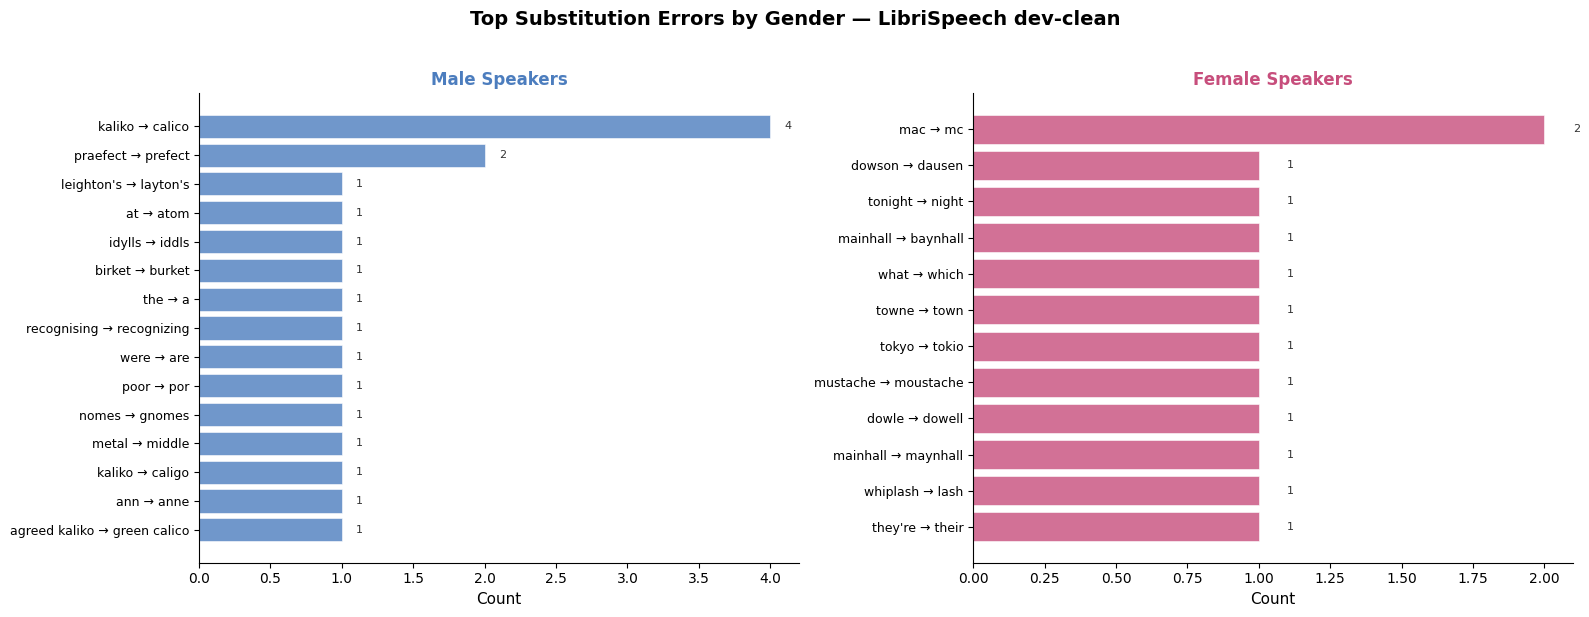


 Error analysis figure saved → /kaggle/working/figures/error_analysis_by_gender.png


In [24]:
# ============================================================
# CELL 10: Error Analysis — Top Transcription Errors by Gender
# ============================================================
from jiwer import process_words
from collections import Counter


def get_substitution_errors(refs, hyps):
    """
    Extract word-level substitution errors: (ref_word, hyp_word, count).
    Uses jiwer's word alignment.
    """
    sub_counter = Counter()
    for ref, hyp in zip(refs, hyps):
        try:
            result = process_words(ref, hyp)
            for chunk in result.alignments[0]:
                if chunk.type == 'substitute':
                    ref_words = ref.split()[chunk.ref_start_idx:chunk.ref_end_idx]
                    hyp_words = hyp.split()[chunk.hyp_start_idx:chunk.hyp_end_idx]
                    sub_counter[(' '.join(ref_words), ' '.join(hyp_words))] += 1
        except Exception:
            pass
    return sub_counter.most_common(20)


# ── Gather errors by gender ──────────────────────────────────
gender_data = {'M': {'refs': [], 'hyps': []},
               'F': {'refs': [], 'hyps': []},
               'U': {'refs': [], 'hyps': []}}

for utt in utterances:
    res = asr_results.get(utt.utt_id)
    if res and utt.gender in gender_data:
        gender_data[utt.gender]['refs'].append(res['ref'])
        gender_data[utt.gender]['hyps'].append(res['pred'])


# ── WER by gender ────────────────────────────────────────────
print(' WER by Gender:')
for g, data in gender_data.items():
    if data['refs']:
        g_wer = compute_wer(data['refs'], data['hyps'])
        print(f'   {g}: WER = {g_wer:.3f}  (n={len(data["refs"])})')


# ── Plot top substitution errors ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top Substitution Errors by Gender — LibriSpeech dev-clean',
             fontsize=14, fontweight='bold', y=1.02)

plot_genders = [('M', '#4c7dbe', 'Male'), ('F', '#c74e7c', 'Female')]
for ax, (g, color, label) in zip(axes, plot_genders):
    data = gender_data.get(g, {'refs': [], 'hyps': []})
    if not data['refs']:
        ax.set_title(f'{label}: no data')
        continue

    top_subs = get_substitution_errors(data['refs'], data['hyps'])[:15]
    if not top_subs:
        ax.set_title(f'{label}: no substitutions found')
        continue

    labels_plot = [f'{r} → {h}' for (r, h), _ in top_subs]
    counts_plot = [c for _, c in top_subs]

    bars = ax.barh(range(len(labels_plot)), counts_plot, color=color, alpha=0.8,
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(labels_plot)))
    ax.set_yticklabels(labels_plot, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Count', fontsize=11)
    ax.set_title(f'{label} Speakers', fontsize=12, color=color, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    for bar, cnt in zip(bars, counts_plot):
        ax.text(cnt + 0.1, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=8, color='#333')

plt.tight_layout()
fig.savefig(FIG_DIR / 'error_analysis_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n Error analysis figure saved → {FIG_DIR}/error_analysis_by_gender.png')

## 8. Sensitivity Analysis

This analysis studies how the temporal granularity of LIME-TS affects the validity scores, helping assess whether the explanation quality is stable across segment durations.

In [14]:
K_VALUES = [1, 3, 5]

Running duration sensitivity over 50 utterances …

  dur_ms = 50 ms


LIME-TS 50ms:   0%|          | 0/50 [00:00<?, ?it/s]

  → 50 rows collected

  dur_ms = 70 ms


LIME-TS 70ms:   0%|          | 0/50 [00:00<?, ?it/s]

  → 50 rows collected

  dur_ms = 90 ms


LIME-TS 90ms:   0%|          | 0/50 [00:00<?, ?it/s]

  → 50 rows collected

Duration sensitivity cached → /kaggle/working/cache/duration_sensitivity.pkl
   dur_ms  k  validity
0      50  1   0.09375
1      50  3   0.15625
2      50  5   0.25000
3      70  1   0.00000
4      70  3   0.06250
5      70  5   0.12500
6      90  1   0.00000
7      90  3   0.12500
8      90  5   0.18750


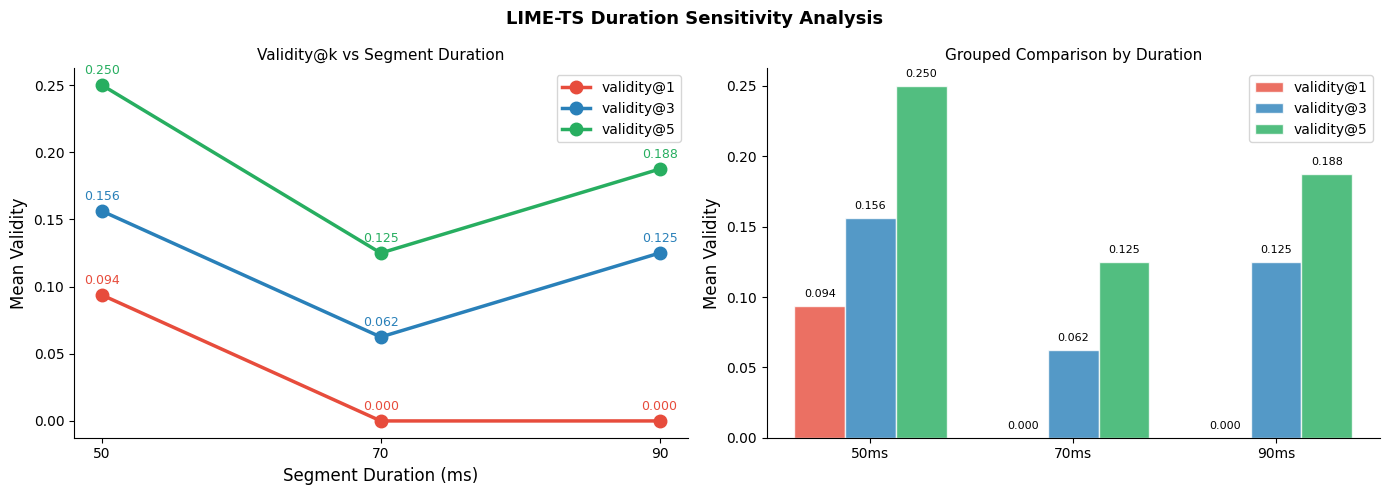


Duration sensitivity figure saved → /kaggle/working/figures/duration_sensitivity.png

Duration Sensitivity Summary:
k            1       3       5
dur_ms                        
50      0.0938  0.1562  0.2500
70      0.0000  0.0625  0.1250
90      0.0000  0.1250  0.1875


In [25]:
# ============================================================
# CELL 11: Duration Sensitivity — 50ms, 70ms, 90ms Comparison
# ============================================================
import pickle
DUR_CACHE  = CACHE_DIR / 'duration_sensitivity.pkl'
DUR_VALUES = [50, 70, 90]
DUR_SUBSET = [u for u in utterances[:50] if len(u.phonemes) > 0 and u.utt_id in asr_results]
K_VALUES   = [1, 3, 5]

# ── validity_at_k helper (mask-and-check ground truth) ──────
def validity_at_k(utt, imp, k_values):
    """Returns dict of validity@k using mask-and-check ground truth."""
    if imp is None or len(imp) == 0:
        return {f'validity@{k}': float('nan') for k in k_values}
    n_ph = len(utt.phonemes)
    ref = asr_results.get(utt.utt_id, {}).get('pred', '')
    # Ground truth: which phonemes change ASR output when masked?
    important = set()
    for p_idx in range(n_ph):
        try:
            ph  = utt.phonemes[p_idx]
            wav = utt.waveform.clone()
            s   = int(ph['start'] * TARGET_SR)
            e   = int(ph['end']   * TARGET_SR)
            wav[s:e] = 0.0
            if transcribe(wav) != ref:
                important.add(p_idx)
        except Exception:
            pass
    if not important:
        return {f'validity@{k}': float('nan') for k in k_values}
    rank = np.argsort(imp)[::-1]
    return {f'validity@{k}': 1.0 if bool(set(rank[:k]) & important) else 0.0
            for k in k_values}

# ── Run or load from cache ───────────────────────────────────
if DUR_CACHE.exists():
    print('Loading cached duration sensitivity results …')
    with open(DUR_CACHE, 'rb') as f:
        dur_records = pickle.load(f)
else:
    dur_records = {}
    print(f'Running duration sensitivity over {len(DUR_SUBSET)} utterances …')
    for dur_ms in DUR_VALUES:
        print(f'\n  dur_ms = {dur_ms} ms')
        expl     = LIMEExplainerTS(dur_ms=dur_ms, n_samples=N_SAMPLES_LIME)
        rec_list = []
        for utt in tqdm(DUR_SUBSET, desc=f'LIME-TS {dur_ms}ms'):
            try:
                imp = expl.explain_projected(utt)
                v   = validity_at_k(utt, imp, K_VALUES)
                rec_list.append({'utt_id': utt.utt_id, 'gender': utt.gender, **v})
            except Exception as e:
                print(f'  {utt.utt_id}: {e}')
            torch.cuda.empty_cache()
        dur_records[dur_ms] = pd.DataFrame(rec_list)
        print(f'  → {len(rec_list)} rows collected')
    with open(DUR_CACHE, 'wb') as f:
        pickle.dump(dur_records, f)
    print(f'\nDuration sensitivity cached → {DUR_CACHE}')

# ── Build summary df ─────────────────────────────────────────
dur_summary = []
for dur_ms, df_dur in dur_records.items():
    for k in K_VALUES:
        col = f'validity@{k}'
        val = df_dur[col].dropna().mean() if col in df_dur.columns else float('nan')
        dur_summary.append({'dur_ms': dur_ms, 'k': k, 'validity': val})
dur_sum_df = pd.DataFrame(dur_summary)
print(dur_sum_df)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # axes defined here
fig.suptitle('LIME-TS Duration Sensitivity Analysis', fontsize=13, fontweight='bold')
colors_k = {1: '#e74c3c', 3: '#2980b9', 5: '#27ae60'}

# Left: line plot
ax = axes[0]
for k in K_VALUES:
    subset = dur_sum_df[dur_sum_df['k'] == k]
    ax.plot(subset['dur_ms'], subset['validity'],
            marker='o', linewidth=2.5, markersize=9,
            label=f'validity@{k}', color=colors_k[k])
    for _, row in subset.iterrows():
        ax.annotate(f'{row["validity"]:.3f}',
                    (row['dur_ms'], row['validity']),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9, color=colors_k[k])
ax.set_xlabel('Segment Duration (ms)', fontsize=12)
ax.set_ylabel('Mean Validity', fontsize=12)
ax.set_xticks(DUR_VALUES)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Validity@k vs Segment Duration', fontsize=11)

# Right: grouped bar chart
ax2   = axes[1]
x_pos = np.arange(len(DUR_VALUES))
width = 0.25
offsets = [-width, 0, width]
for i, k in enumerate(K_VALUES):
    subset = dur_sum_df[dur_sum_df['k'] == k].sort_values('dur_ms')
    vals   = subset['validity'].values
    bars   = ax2.bar(x_pos + offsets[i], vals, width,
                     label=f'validity@{k}', color=colors_k[k],
                     alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{d}ms' for d in DUR_VALUES], fontsize=10)
ax2.set_ylabel('Mean Validity', fontsize=12)
ax2.set_title('Grouped Comparison by Duration', fontsize=11)
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.savefig(FIG_DIR / 'duration_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nDuration sensitivity figure saved → {FIG_DIR}/duration_sensitivity.png')
print('\nDuration Sensitivity Summary:')
print(dur_sum_df.pivot(index='dur_ms', columns='k', values='validity').round(4))

## 9. Qualitative Visualization

The final section produces waveform-level visualizations and attribution overlays so the explanation outputs can be inspected qualitatively alongside the aligned phoneme structure.

visualize_lime_attributions redefined with fix.

 Generating visualization for: 1272-128104-0000
   Transcript: "mister quilter is the apostle of the middle classes and we are glad to welcome h"
   # phonemes: 73

  Computing attributions (quick mode: n_samples=50) …
 Saved → /kaggle/working/figures/heatmap_1272-128104-0000.png


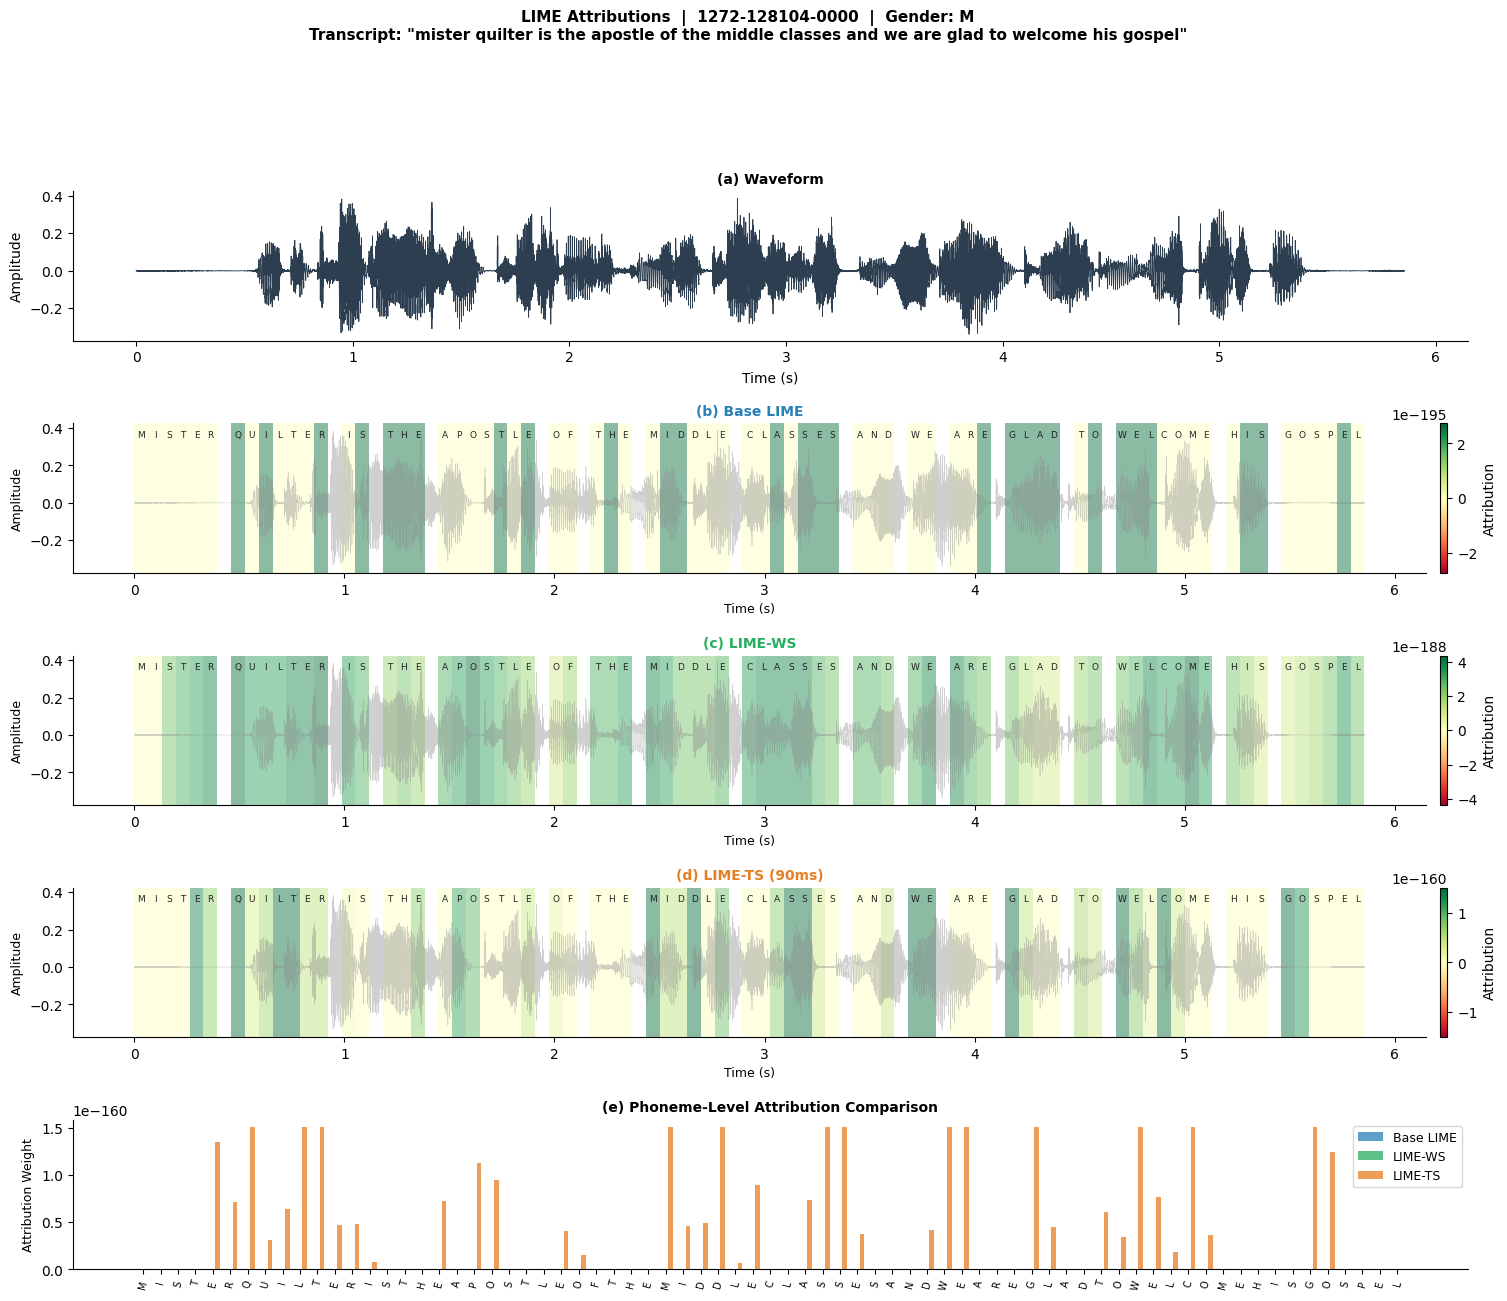


 Generating additional visualizations …


Visualizations:   0%|          | 0/3 [00:00<?, ?it/s]

 Saved → /kaggle/working/figures/heatmap_1272-128104-0001.png
 Saved → /kaggle/working/figures/heatmap_1272-128104-0002.png
 Saved → /kaggle/working/figures/heatmap_1272-128104-0003.png

  All visualizations saved to: /kaggle/working/figures

 Output files:
   .virtual_documents/__notebook_source__.ipynb  (57.5 KB)
   cache/alignments.pkl  (85577.9 KB)
   cache/asr_predictions.pkl  (45.8 KB)
   cache/duration_sensitivity.pkl  (6.2 KB)
   figures/duration_sensitivity.png  (126.1 KB)
   figures/error_analysis_by_gender.png  (114.7 KB)
   figures/heatmap_1272-128104-0000.png  (418.4 KB)
   figures/heatmap_1272-128104-0001.png  (394.3 KB)
   figures/heatmap_1272-128104-0002.png  (350.1 KB)
   figures/heatmap_1272-128104-0003.png  (335.2 KB)
   table1_validity.html  (3.0 KB)


In [26]:
# ── Fixed Cell 12 ──────────────────────────────────────────
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def visualize_lime_attributions(
    utt, imp_base, imp_ws, imp_ts, save_path=None, show=True
):
    wav    = utt.waveform.cpu().numpy()
    t_axis = np.arange(len(wav)) / TARGET_SR
    n_ph   = len(utt.phonemes)
    n_s    = len(wav)

    def build_heatmap_signal(importances, phonemes, n_samples):
        sig = np.zeros(n_samples)
        if importances is None:
            return sig
        for i, ph in enumerate(phonemes):
            if i >= len(importances):
                break
            s = int(ph['start'] * TARGET_SR)
            e = int(ph['end']   * TARGET_SR)
            sig[s:e] = importances[i]
        return sig

    h_b  = build_heatmap_signal(imp_base, utt.phonemes, n_s)
    h_ws = build_heatmap_signal(imp_ws,   utt.phonemes, n_s)
    h_ts = build_heatmap_signal(imp_ts,   utt.phonemes, n_s)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        f'LIME Attributions  |  {utt.utt_id}  |  Gender: {utt.gender}\n'
        f'Transcript: "{utt.transcript[:90]}"',
        fontsize=11, fontweight='bold', y=1.01
    )
    gs   = gridspec.GridSpec(5, 1, hspace=0.55)
    cmap = plt.cm.RdYlGn

    def plot_waveform_heatmap(ax, heatmap, imp_arr, title, color):
        vabs = np.abs(heatmap).max() or 1.0
        norm = Normalize(vmin=-vabs, vmax=vabs)
        ax.plot(t_axis, wav, color='#888', alpha=0.4, linewidth=0.4)

        safe_imp = imp_arr if imp_arr is not None else np.array([])  # ← THE FIX
        for ph_i, ph in enumerate(utt.phonemes):
            s = int(ph['start'] * TARGET_SR)
            e = int(ph['end']   * TARGET_SR)
            if ph_i >= len(safe_imp):   # ← use local safe_imp, not outer imp_base
                continue
            imp_val = heatmap[s] if s < n_s else 0.0
            rgba    = cmap(norm(imp_val))
            ax.axvspan(ph['start'], ph['end'], alpha=0.45, color=rgba, linewidth=0)
            mid = (ph['start'] + ph['end']) / 2
            ax.text(mid, ax.get_ylim()[1] * 0.8,
                    ph['label'], ha='center', va='bottom', fontsize=6.5, color='#222')

        sm = ScalarMappable(norm=norm, cmap=cmap)
        plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01, label='Attribution')
        ax.set_title(title, fontsize=10, color=color, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.set_ylabel('Amplitude', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(t_axis, wav, color='#2c3e50', linewidth=0.6)
    ax0.set_title('(a) Waveform', fontsize=10, fontweight='bold')
    ax0.set_ylabel('Amplitude'); ax0.set_xlabel('Time (s)')
    ax0.spines[['top', 'right']].set_visible(False)

    pairs = [
        (gs[1], h_b,  imp_base, '(b) Base LIME',      '#2980b9'),
        (gs[2], h_ws, imp_ws,   '(c) LIME-WS',         '#27ae60'),
        (gs[3], h_ts, imp_ts,   '(d) LIME-TS (90ms)',  '#e67e22'),
    ]
    for gs_slot, hmap, imp_arr, ttl, clr in pairs:
        ax = fig.add_subplot(gs_slot)
        plot_waveform_heatmap(ax, hmap, imp_arr, ttl, clr)

    ax4 = fig.add_subplot(gs[4])
    x   = np.arange(n_ph)
    w   = 0.27
    ph_labels = [ph['label'] for ph in utt.phonemes]

    def safe_bar(imp, offset, color, label):
        vals = imp[:n_ph] if imp is not None else np.zeros(n_ph)
        ax4.bar(x + offset, vals, w, label=label, color=color, alpha=0.75)

    safe_bar(imp_base, -w, '#2980b9', 'Base LIME')
    safe_bar(imp_ws,    0, '#27ae60', 'LIME-WS')
    safe_bar(imp_ts,    w, '#e67e22', 'LIME-TS')

    ax4.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax4.set_xticks(x)
    ax4.set_xticklabels(ph_labels, rotation=75, fontsize=7)
    ax4.set_ylabel('Attribution Weight', fontsize=9)
    ax4.set_title('(e) Phoneme-Level Attribution Comparison', fontsize=10, fontweight='bold')
    ax4.legend(loc='upper right', fontsize=9)
    ax4.spines[['top', 'right']].set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f' Saved → {save_path}')
    if show:
        plt.show()
    plt.close(fig)

print("visualize_lime_attributions redefined with fix.")

# ── Demo: explain and visualize a sample utterance ──────────
demo_utt = utterances[0]
print(f'\n Generating visualization for: {demo_utt.utt_id}')
print(f'   Transcript: "{demo_utt.transcript[:80]}"')
print(f'   # phonemes: {len(demo_utt.phonemes)}')

# Run LIME (use small n_samples for fast demo)
print('\n  Computing attributions (quick mode: n_samples=50) …')
b_expl  = LIMEExplainerBase(n_samples=50)
ws_expl = LIMEExplainerWS(window=5, n_samples=50)
ts_expl = LIMEExplainerTS(dur_ms=90, n_samples=50)

imp_b  = b_expl.explain(demo_utt)
imp_w  = ws_expl.explain_and_project(demo_utt)
imp_t  = ts_expl.explain_projected(demo_utt)

visualize_lime_attributions(
    demo_utt, imp_b, imp_w, imp_t,
    save_path=FIG_DIR / f'heatmap_{demo_utt.utt_id}.png',
    show=True
)

# ── Generate visualizations for 3 more utterances ───────────
print('\n Generating additional visualizations …')
for utt in tqdm(utterances[1:4], desc='Visualizations'):
    try:
        i_b = LIMEExplainerBase(n_samples=50).explain(utt)
        i_w = LIMEExplainerWS(n_samples=50).explain_and_project(utt)
        i_t = LIMEExplainerTS(n_samples=50).explain_projected(utt)
        visualize_lime_attributions(
            utt, i_b, i_w, i_t,
            save_path=FIG_DIR / f'heatmap_{utt.utt_id}.png',
            show=False
        )
    except Exception as e:
        print(f'  {utt.utt_id}: {e}')

print(f'\n  All visualizations saved to: {FIG_DIR}')
print('\n Output files:')
for p in sorted(WORK_DIR.rglob('*')):
    if p.is_file():
        sz = p.stat().st_size / 1024
        print(f'   {p.relative_to(WORK_DIR)}  ({sz:.1f} KB)')